Setup

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

Load Data

Assumes this folder structure

train/benign/

train/malignant/

test/benign/

test/malignant


### Step 1: Mount Google Drive

Run this cell to connect your Google Drive to this Colab session. You'll be prompted to authorize the connection.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

base_image_dir = '/content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images'

# Define paths for test set
test_benign_dir = os.path.join(base_image_dir, 'test', 'benign')
test_malignant_dir = os.path.join(base_image_dir, 'test', 'malignant')

# Define paths for train set
train_benign_dir = os.path.join(base_image_dir, 'train', 'benign')
train_malignant_dir = os.path.join(base_image_dir, 'train', 'malignant')

# Function to count files in a directory
def count_images(directory_path):
    if os.path.exists(directory_path):
        # Count only files, not subdirectories
        return len([name for name in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, name))])
    else:
        return 0

# Get counts
count_test_benign = count_images(test_benign_dir)
count_test_malignant = count_images(test_malignant_dir)
count_train_benign = count_images(train_benign_dir)
count_train_malignant = count_images(train_malignant_dir)

# Print results
print(f"Number of images in {test_benign_dir}: {count_test_benign}")
print(f"Number of images in {test_malignant_dir}: {count_test_malignant}")
print(f"Number of images in {train_benign_dir}: {count_train_benign}")
print(f"Number of images in {train_malignant_dir}: {count_train_malignant}")

Number of images in /content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images/test/benign: 593
Number of images in /content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images/test/malignant: 7
Number of images in /content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images/train/benign: 2129
Number of images in /content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images/train/malignant: 31


In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# IMPORTANT: Replace '/content/drive/MyDrive/your_image_data_folder/train'
# and '/content/drive/MyDrive/your_image_data_folder/test' with the actual paths
# to your 'train' and 'test' image folders in Google Drive.

# VERIFY THIS PATH AND THE SUBDIRECTORY STRUCTURE (e.g., /train/benign, /train/malignant)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    #'/content/drive/MyDrive/your_image_data_folder/train',
    '/content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images/train',# Example path, replace with your actual path
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# VERIFY THIS PATH AND THE SUBDIRECTORY STRUCTURE (e.g., /test/benign, /test/malignant)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images/test', # Example path, replace with your actual path
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 2160 files belonging to 2 classes.
Found 600 files belonging to 2 classes.


Normalize Data

In [5]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Build CNN Model


In [6]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [7]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.9745 - loss: 0.1272 - val_accuracy: 0.9883 - val_loss: 0.0836
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.9856 - loss: 0.0978 - val_accuracy: 0.9883 - val_loss: 0.0728
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 260ms/step - accuracy: 0.9856 - loss: 0.0897 - val_accuracy: 0.9883 - val_loss: 0.0638
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 254ms/step - accuracy: 0.9856 - loss: 0.0855 - val_accuracy: 0.9883 - val_loss: 0.0590
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.9856 - loss: 0.0833 - val_accuracy: 0.9883 - val_loss: 0.0623
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.9856 - loss: 0.0848 - val_accuracy: 0.9883 - val_loss: 0.0608
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.9856 - loss: 0.0780 - val_accuracy: 0.9883 - val_loss: 0.0705
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9856 - loss: 0.0778 - val_accura

Evaluate Model


In [8]:
loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.9883 - loss: 0.0595
Test Accuracy: 0.9883


Occlusion Sensitivity Map

In [9]:
def occlusion_sensitivity(model, image, label, patch_size=20, stride=10):
    image = image.numpy()
    h, w, _ = image.shape
    heatmap = np.zeros((h, w))

    # Get baseline prediction
    baseline = model.predict(image[np.newaxis, ...])[0][0]

    for y in range(0, h, stride):
        for x in range(0, w, stride):
            occluded = image.copy()
            occluded[y:y+patch_size, x:x+patch_size, :] = 0.5  # gray patch

            pred = model.predict(occluded[np.newaxis, ...])[0][0]

            impact = baseline - pred
            heatmap[y:y+patch_size, x:x+patch_size] += impact

    return heatmap

Visualize occlusion map

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━

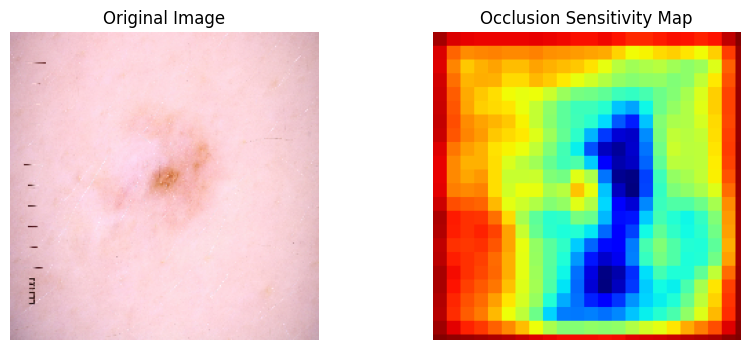

In [10]:
# Take one image from test set
for images, labels in test_ds.take(1):
    sample_img = images[0]
    sample_label = labels[0]

heatmap = occlusion_sensitivity(model, sample_img, sample_label)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample_img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Occlusion Sensitivity Map")
plt.axis('off')

plt.show()


Interpretation

* Bright/red regions = important for prediction
* Dark/blue regions = less important

Why this matters:

* Helps identify **regions of interest (ROI)**
* Can guide **better cropping or preprocessing**
* Improves **model trust and explainability**



Optional Improvements

* Use **transfer learning** (e.g., MobileNet, ResNet)
* Tune patch size for occlusion
* Apply smoothing to heatmap